SOLO - S-ADCP transect

DOPPIOE - Numerical

LATTE - drifter, drifter and sattellite (multimodel) 

Keep it simple, be like water, flow

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import netCDF4 as nc
import xarray as xr

import sys
sys.path.append("/home/z5297792/UNSW-MRes/MRes/modules") 
from utils import axis_ratio_from_Q, tangential_velocity#, #fit_psi_params


In [2]:
def latte(xi, yi, ui, vi):
    from scipy.optimize import least_squares
    xi, yi, ui, vi = map(lambda a: np.asarray(a, float), (xi, yi, ui, vi))
    m = np.isfinite(xi) & np.isfinite(yi) & np.isfinite(ui) & np.isfinite(vi)
    x, y, u_i, v_i = xi[m], yi[m], ui[m], vi[m]
    n = x.size
    if n < 3:
        return np.nan, np.nan, np.nan, np.full((2,2), np.nan), np.nan, np.nan

    p0 = np.array([x.mean(), y.mean(), 1., 0., 1.])  # xc,yc,Aq11,Aq12,Aq22

    def fun(p):
        xc,yc,a11,a12,a22 = p
        dx, dy = x-xc, y-yc
        u = -2*a22*dy - 2*a12*dx
        v =  2*a11*dx + 2*a12*dy
        r = np.empty(2*n); r[:n]=u-u_i; r[n:]=v-v_i
        return r

    def jac(p):
        xc,yc,a11,a12,a22 = p
        dx, dy = x-xc, y-yc
        J = np.zeros((2*n,5))
        # u = -2*Aq22*(y-yc) - 2*Aq12*(x-xc)
        J[:n,0], J[:n,1], J[:n,3], J[:n,4] = 2*a12, 2*a22, -2*dx, -2*dy
        # v = 2*Aq11*(x-xc) + 2*Aq12*(y-yc)
        J[n:,0], J[n:,1], J[n:,2], J[n:,3] = -2*a11, -2*a12, 2*dx, 2*dy
        return J

    xc,yc,a11,a12,a22 = least_squares(fun, p0, jac=jac).x

    dx, dy = x-xc, y-yc
    u = -2*a22*dy - 2*a12*dx
    v =  2*a11*dx + 2*a12*dy
    err2 = ((u-u_i)**2 + (v-v_i)**2).sum()
    tot2 = ((u_i-u_i.mean())**2 + (v_i-v_i.mean())**2).sum()
    r2 = 1 - err2/tot2 if tot2 > 0 else np.nan

    w = 2*(a11+a22)
    AQ = np.array([[a11,a12],[a12,a22]])
    det = AQ[0,0]*AQ[1,1] - AQ[0,1]*AQ[1,0]
    A = np.sign(a11)*np.sqrt(abs(det))
    Q = AQ/A if A != 0 else np.full((2,2), np.nan)

    return xc, yc, w, Q, A, r2

def fit_psi_params(rho2, Qr, vt, A0=None, Rc0=None, plot=False, ax=None,
                   maxfev=10000, Rc_max=1e5, r2_flag=False,
                   rho_plot_max=None, n_curve=400):
    
    from scipy.optimize import curve_fit

    rho2 = np.asarray(rho2, float)
    Qr   = np.asarray(Qr, float)
    vt   = np.asarray(vt, float)

    m = np.isfinite(rho2) & np.isfinite(Qr) & np.isfinite(vt) & (rho2 >= 0) & (Qr != 0)
    if not np.any(m):
        return (np.nan, np.nan, np.nan, np.nan) if r2_flag else (np.nan, np.nan, np.nan)

    rho2 = rho2[m]; Qr = Qr[m]; vt = vt[m]

    # v*_t = v_t * (rho/Qr)
    rho = np.sqrt(rho2)
    vt = vt * (rho / Qr)

    def vt_model(rho2_, A, Rc):
        return 2.0 * A * np.sqrt(rho2_) * np.exp(-rho2_ / (Rc * Rc))

    # initial Rc0 from location of max |vt|
    i = np.nanargmax(np.abs(vt))
    rho_max = rho[i]
    if Rc0 is None:
        Rc0 = max(rho_max * np.sqrt(2.0), 1e-6)

    if A0 is None:
        denom = 2.0 * rho * np.exp(-rho2 / (Rc0 * Rc0))
        ok = np.abs(denom) > 0
        A0 = np.nanmedian(vt[ok] / denom[ok]) if np.any(ok) else 0.0
    if not np.isfinite(A0):
        A0 = 0.0

    try:
        popt, _ = curve_fit(
            vt_model, rho2, vt, p0=[A0, Rc0],
            bounds=([-np.inf, 1e-8], [np.inf, np.inf]),
            maxfev=maxfev
        )
        A_opt, Rc_opt = popt
    except Exception:
        A_opt, Rc_opt = A0, Rc0

    if (not np.isfinite(Rc_opt)) or (Rc_opt > Rc_max):
        A_opt, Rc_opt = A0, Rc0

    psi0_opt = -A_opt * Rc_opt**2

    vt_fit = vt_model(rho2, A_opt, Rc_opt)
    ss_res = np.sum((vt - vt_fit)**2)
    ss_tot = np.sum((vt - vt.mean())**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

    if plot:
        if ax is None:
            _, ax = plt.subplots()

        if rho_plot_max is None:
            rho_plot_max = float(np.nanmax(rho)) if rho.size else Rc_opt

        r_grid = np.linspace(0.0, rho_plot_max, n_curve)
        vt_grid = vt_model(r_grid**2, A_opt, Rc_opt)

        ax.scatter(rho, np.abs(vt), s=20, marker='.', label='Observed')
        ax.plot(r_grid, np.abs(vt_grid), lw=3, label='Fit')
        ax.axvline(Rc_opt/np.sqrt(2), ls='--', lw=3, label=r'$\rho_{\max}$')

        ax.set_xlabel(r'$\rho$')
        ax.set_ylabel(r'$|v_t^\star|$')
        ax.set_title(f'A={A_opt:.4g}, Rc={Rc_opt:.4g}, psi0={psi0_opt:.4g}, R²={r2:.2f}')
        ax.legend()

    return (Rc_opt, psi0_opt, A_opt, r2) if r2_flag else (Rc_opt, psi0_opt, A_opt)
    

### Drifter Data

In [3]:
drifter_path = '/srv/scratch/z5297792/ESP_Paper_Data/drifter_data_CCE_2023_6h.nc'

drifter_dataset = nc.Dataset(drifter_path, mode='r')

u_drif, v_drif = drifter_dataset['ve'][:].data, drifter_dataset['vn'][:].data
lon_drif, lat_drif = drifter_dataset['longitude'][:].data, drifter_dataset['latitude'][:].data
ID_drif =  drifter_dataset['ID'][:]
secs = drifter_dataset['time'][:].data
tim_drif = [datetime.utcfromtimestamp(t).strftime('%Y-%m-%d %H:%M:%S') for t in secs]
df_drifters = pd.DataFrame({'ID': ID_drif.astype(int), 'Lon': lon_drif, 'Lat': lat_drif, 'u': u_drif, 'v': v_drif, 'time': tim_drif})
df_drifters['time'] = pd.to_datetime(df_drifters['time'])
df_drifters = df_drifters[np.hypot(df_drifters.u, df_drifters.v) < 100]
df_drifters = df_drifters.reset_index().drop(columns=['index'])
df_drifters = df_drifters[df_drifters.time < pd.Timestamp('2024-02-10 00:00:00')]

theta_mean, phi_mean = np.float64(154.3), np.float64(-37.9)
df_drifters['x'] = (df_drifters.Lon - theta_mean) * 111000 * np.cos(np.deg2rad(phi_mean))
df_drifters['y'] = (df_drifters.Lat - phi_mean) * 111000

df_drifters.head()


,ID,Lon,Lat,u,v,time,x,y
0,300534062034380,153.975,-37.651,0.39605,0.45606,2023-10-19 12:00:00,-28466.208360,27639.0
1,300534062034380,154.095,-37.579,0.47131,0.32648,2023-10-19 18:00:00,-17955.608350,35631.0
2,300534062034380,154.206,-37.523,0.47029,0.15047,2023-10-20 00:00:00,-8233.303341,41847.0
3,300534062034380,154.325,-37.520,0.49572,-0.06028,2023-10-20 06:00:00,2189.708335,42180.0
4,300534062034380,154.448,-37.547,0.45842,-0.19557,2023-10-20 12:00:00,12963.073346,39183.0


In [4]:
start = df_drifters.time.min() + pd.Timedelta(days=1)
end   = df_drifters.time.max() - pd.Timedelta(days=1)
times = pd.date_range(start, end, freq="D")

T  = df_drifters["time"].to_numpy()
XY = df_drifters[["x","y"]].to_numpy()
UV = df_drifters[["u","v"]].to_numpy()
ID = df_drifters["ID"].to_numpy()

results = []
dic_drif = {}

for t in times:
    m = (T >= (t - pd.Timedelta(days=1))) & (T <= (t + pd.Timedelta(days=1)))
    xi, yi = XY[m].T
    ui, vi = UV[m].T

    dic_drif[t] = pd.DataFrame(
        {"xi": xi, "yi": yi, "ui": ui, "vi": vi, "ID": ID[m]}
    )

    xc, yc, w, Q, A, r2 = latte(xi, yi, ui, vi)
    results.append({"xc": xc, "yc": yc, "w": w, "Q": Q, "A": A, "r2": r2, "time": t})

df_drif_res = pd.DataFrame(results)
df_drif_res["alpha"] = [axis_ratio_from_Q(Q) for Q in df_drif_res["Q"].to_list()]
df_drif_res


,xc,yc,w,Q,A,r2,time,alpha
0,-3294.287927,-5573.143352,-0.000027,"[[1.263598260460861, -0.10707400872613092], [-...",-0.000007,0.991515,2023-10-20 12:00:00,1.287155
1,1945.671980,-1983.946961,-0.000031,"[[1.329320808603612, -0.045006095106227315], [...",-0.000007,0.980386,2023-10-21 12:00:00,1.332819
2,-5712.588428,-4674.576006,-0.000031,"[[1.0579383857758031, 0.05131669545893002], [0...",-0.000008,0.959225,2023-10-22 12:00:00,1.078132
3,-11550.619818,-7158.844551,-0.000033,"[[1.027174531531638, 0.125849825274393], [0.12...",-0.000008,0.928635,2023-10-23 12:00:00,1.135361
4,-12920.830789,-1271.000510,-0.000032,"[[1.0737560405562327, -0.051220084976039734], ...",-0.000008,0.916079,2023-10-24 12:00:00,1.090494
...,...,...,...,...,...,...,...,...
107,-316915.391322,79699.292141,-0.000036,"[[1.1809806981325994, -0.24468992803827475], [...",-0.000009,0.974400,2024-02-04 12:00:00,1.322006
108,-318831.676910,73550.482819,-0.000039,"[[0.9598894244962433, -0.2878569758973735], [-...",-0.000009,0.949578,2024-02-05 12:00:00,1.343894
109,-314499.721779,64718.385922,-0.000034,"[[0.7170437098276522, 0.19032273340433548], [0...",-0.000008,0.874984,2024-02-06 12:00:00,1.491881
110,-316009.011653,66870.755713,-0.000042,"[[0.6369083577037351, 0.26636756725649563], [0...",-0.000009,0.854350,2024-02-07 12:00:00,1.745487


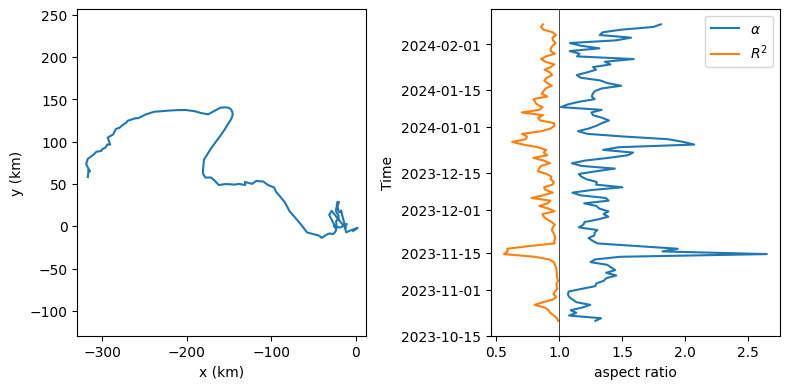

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(8,4), sharey=False)
axs[0].plot(df_drif_res.xc/1e3, df_drif_res.yc/1e3); axs[0].axis('equal')
axs[0].set_xlabel('x (km)'); axs[0].set_ylabel('y (km)')
axs[1].plot(df_drif_res.alpha, df_drif_res.time, label=r'$\alpha$')
axs[1].set_xlabel('aspect ratio'); axs[1].set_ylabel('Time')
axs[1].plot(df_drif_res.r2, df_drif_res.time, label=r'$R^2$')
axs[1].legend(); axs[1].axvline(1, lw=.5, color='k')
plt.tight_layout()


### Satellite Data

In [6]:
ssh_path = '/srv/scratch/z5297792/ESP_Paper_Data/sat_data_IMOS_drifters.nc'
ds_nc = nc.Dataset(ssh_path)

lon, lat = ds_nc['LONGITUDE'][:].data, ds_nc['LATITUDE'][:].data
u, v = ds_nc['UCUR'][:].data, ds_nc['VCUR'][:].data

t = pd.Timestamp("1985-01-01 00:00:00", tz="UTC") + pd.to_timedelta(ds_nc['TIME'][:].data, "D")
t = pd.DatetimeIndex(t).tz_convert(None)

u, v = np.where(np.abs(u) < 4.9, u, np.nan), np.where(np.abs(v) < 4.9, v, np.nan)

ds = xr.Dataset(
    {"u": (("time","lat","lon"), u), "v": (("time","lat","lon"), v)},
    coords={"time": t, "lat": lat, "lon": lon},
)

theta_mean, phi_mean = np.float64(154.3), np.float64(-37.9)
lon2d, lat2d = np.meshgrid(lon, lat)
ds = ds.assign_coords(
    x=(("lat","lon"), (lon2d-theta_mean)*111000*np.cos(np.deg2rad(phi_mean))),
    y=(("lat","lon"), (lat2d-phi_mean)*111000),
)

t0, t1 = ds.time.to_index()[0], ds.time.to_index()[-1]
start = t0.normalize() + pd.Timedelta(hours=6) + pd.Timedelta(days=int(t0 > t0.normalize() + pd.Timedelta(hours=6)))
end   = t1.normalize() + pd.Timedelta(hours=6) - pd.Timedelta(days=int(t1 < t1.normalize() + pd.Timedelta(hours=6)))
t6am = pd.date_range(start, end, freq="1D")

ds_sat = ds.interp(time=t6am)

# Find land mask
land_mask = np.isnan(ds.u.isel(time=0)) & np.isnan(ds.v.isel(time=0))  # (lat, lon)
ds = ds.assign(land_mask=land_mask)
ds_sat = ds_sat.assign(land_mask=land_mask)

# # Time slice
ds_sat = ds_sat.sel(time=ds_sat.time <= np.datetime64('2024-01-27T06:00:00.000000000'))

ds_sat


<xarray.Dataset> Size: 3MB
Dimensions:    (time: 101, lat: 41, lon: 46)
Coordinates:
  * lat        (lat) float64 328B -42.0 -41.8 -41.6 -41.4 ... -34.4 -34.2 -34.0
  * lon        (lon) float64 368B 149.0 149.2 149.4 149.6 ... 157.6 157.8 158.0
    x          (lat, lon) float64 15kB -4.642e+05 -4.467e+05 ... 3.241e+05
    y          (lat, lon) float64 15kB -4.551e+05 -4.551e+05 ... 4.329e+05
  * time       (time) datetime64[ns] 808B 2023-10-19T06:00:00 ... 2024-01-27T...
Data variables:
    u          (time, lat, lon) float64 2MB -0.165 -0.2501 ... 0.2664 0.3238
    v          (time, lat, lon) float64 2MB -0.1421 -0.1373 ... -0.4036 -0.314
    land_mask  (lat, lon) bool 2kB False False False False ... False False False

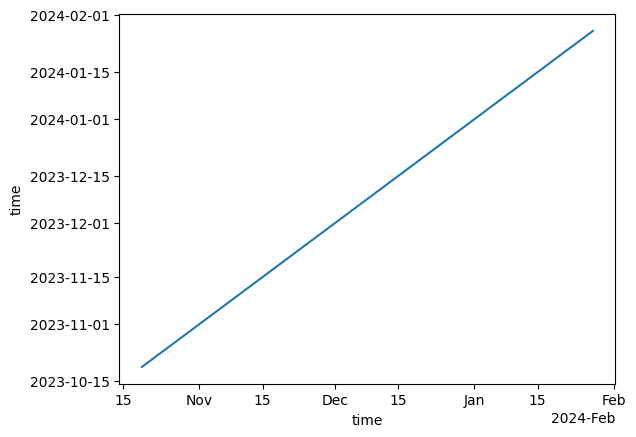

In [7]:
ds_sat.time.plot()

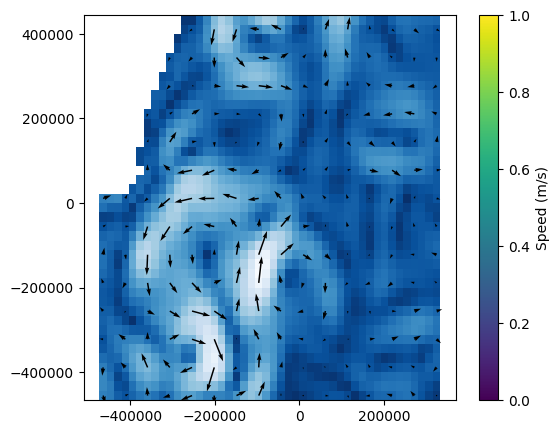

In [8]:
t = '2024-01-21T06:00:00'

u = ds_sat.u.sel(time=t)
v = ds_sat.v.sel(time=t)
speed = np.sqrt(u**2 + v**2)

plt.figure(figsize=(6,5))
plt.pcolormesh(ds_sat.x, ds_sat.y, speed, shading='auto', cmap='Blues_r')

spac = 3
plt.quiver(
    ds_sat.x.values[::spac, ::spac],
    ds_sat.y.values[::spac, ::spac],
    u.values[::spac, ::spac],
    v.values[::spac, ::spac],
    scale=15
)

plt.colorbar(label='Speed (m/s)')
plt.axis('equal')
plt.show()


In [9]:
xc_pre, yc_pre = 0.0, 0.0
q11, q12, q22 = 1.0, 0.0, 1.0

# for the first do the above, but then re do it with the correct Q

rows = []

X = ds_sat.x.values
Y = ds_sat.y.values
xg = X.ravel()
yg = Y.ravel()

T_drif = df_drifters["time"].to_numpy()
rho_core = 35_000.0
dt = pd.Timedelta(days=1)  # ±1 day

dic_mask_data = {}

flag = True
for time in ds_sat.time.values:
    ut = ds_sat.u.sel(time=time).values.ravel()
    vt = ds_sat.v.sel(time=time).values.ravel()

    m = (T_drif >= (time - dt)) & (T_drif <= (time + dt))
    dfm = df_drifters.iloc[np.flatnonzero(m)]
    xd = dfm["x"].to_numpy()
    yd = dfm["y"].to_numpy()
    ud = dfm["u"].to_numpy()
    vd = dfm["v"].to_numpy()
    # xd = np.array([])
    # yd = np.array([])
    # ud = np.array([])
    # vd = np.array([])
    
    xi = np.concatenate([xd, xg])
    yi = np.concatenate([yd, yg])
    ui = np.concatenate([ud, ut])
    vi = np.concatenate([vd, vt])

    dx = xi - xc_pre
    dy = yi - yc_pre
    rho2 = q11*dx*dx + 2*q12*dx*dy + q22*dy*dy

    core = rho2 <= rho_core**2
    xc, yc, w, Q, A, r2 = latte(xi[core], yi[core], ui[core], vi[core])

    if flag:
        xc_pre, yc_pre = xc, yc
        dx = xi - xc_pre
        dy = yi - yc_pre
        rho2 = q11*dx*dx + 2*q12*dx*dy + q22*dy*dy
    
        core = rho2 <= rho_core**2
        xc, yc, w, Q, A, r2 = latte(xi[core], yi[core], ui[core], vi[core])

    dic_mask_data[time] = pd.DataFrame({'xi': xi[core], 'yi': yi[core], 'ui': ui[core], 'vi': vi[core]})

    if np.isfinite(xc) and np.isfinite(yc) and (np.hypot(xc-xc_pre, yc-yc_pre) < 100_000) and (w < 0):
        rows.append(dict(xc=xc, yc=yc, w=w, Q=Q, A=A, r2=r2, time=time))
        xc_pre, yc_pre = xc, yc
        q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]   # update core metric for next step
    else:
        break

df_multimodal_res = pd.DataFrame(rows, columns=["xc","yc","w","Q","A","r2","time"])
df_multimodal_res["alpha"] = [axis_ratio_from_Q(Q) for Q in df_multimodal_res["Q"].to_list()]
df_multimodal_res


,xc,yc,w,Q,A,r2,time,alpha
0,3675.649550,5440.328473,-0.000030,"[[1.2156421394730978, 0.011082508899900265], [...",-0.000007,0.994726,2023-10-19 06:00:00,1.215954
1,3960.719821,4947.833115,-0.000032,"[[1.2313291225386833, 0.07235845042252916], [0...",-0.000008,0.991077,2023-10-20 06:00:00,1.243585
2,3489.788395,5262.281371,-0.000032,"[[1.223995532428482, 0.06314285628024016], [0....",-0.000008,0.991657,2023-10-21 06:00:00,1.233640
3,1366.561319,4343.255427,-0.000029,"[[1.1648244596264439, -0.026497196275979483], ...",-0.000007,0.946008,2023-10-22 06:00:00,1.167104
4,-3613.979269,538.334076,-0.000030,"[[1.1902034306234115, 0.009181037008192932], [...",-0.000007,0.786982,2023-10-23 06:00:00,1.190444
...,...,...,...,...,...,...,...,...
96,-277170.817225,115959.452337,-0.000028,"[[0.886222859526389, -0.1991823803440695], [-0...",-0.000007,0.855621,2024-01-23 06:00:00,1.275157
97,-277303.233579,118153.726429,-0.000026,"[[0.8612266788375882, -0.1859761295050677], [-...",-0.000006,0.858690,2024-01-24 06:00:00,1.283250
98,-276036.683134,119315.200664,-0.000024,"[[0.8309239081483889, -0.2361106209462835], [-...",-0.000006,0.887776,2024-01-25 06:00:00,1.373348
99,-286477.983239,111173.543202,-0.000027,"[[0.7846175417780481, 0.05888541432806775], [0...",-0.000007,0.701036,2024-01-26 06:00:00,1.285844


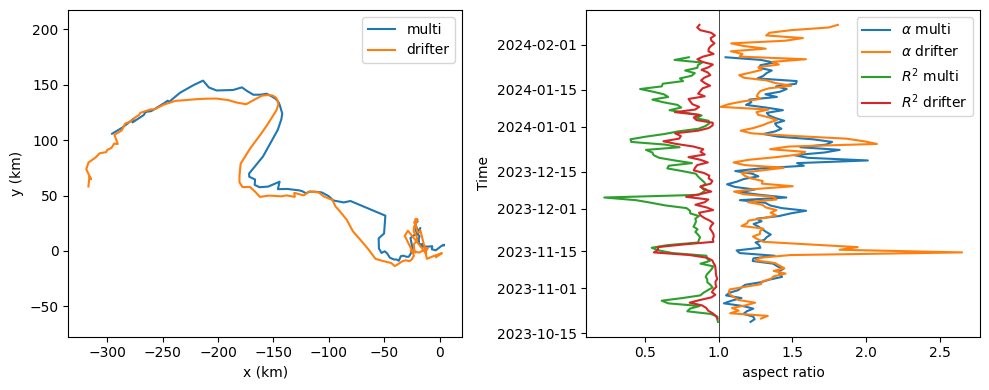

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(10,4), sharey=False)
axs[0].plot(df_multimodal_res.xc/1e3, df_multimodal_res.yc/1e3, label='multi');
axs[0].plot(df_drif_res.xc/1e3, df_drif_res.yc/1e3, label='drifter'); axs[0].axis('equal')
axs[0].set_xlabel('x (km)'); axs[0].set_ylabel('y (km)'); axs[0].legend()

axs[1].plot(df_multimodal_res.alpha, df_multimodal_res.time, label=r'$\alpha$ multi')
axs[1].plot(df_drif_res.alpha, df_drif_res.time, label=r'$\alpha$ drifter')
axs[1].set_xlabel('aspect ratio'); axs[1].set_ylabel('Time')
axs[1].plot(df_multimodal_res.r2, df_multimodal_res.time, label=r'$R^2$ multi')
axs[1].plot(df_drif_res.r2, df_drif_res.time, label=r'$R^2$ drifter')
axs[1].legend(); axs[1].axvline(1, lw=.5, color='k')
plt.tight_layout()


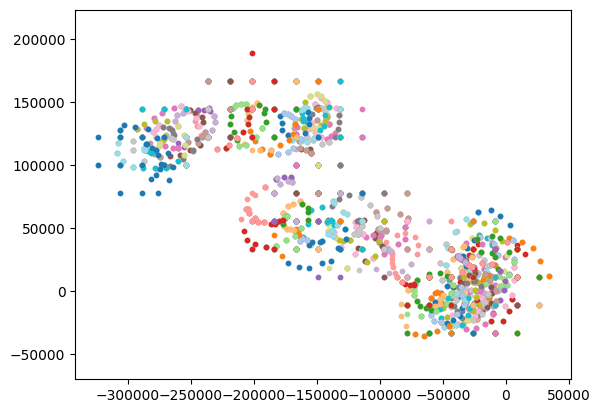

In [11]:
cmap = plt.colormaps['tab20']
for k, (key, df) in enumerate(dic_mask_data.items()):
    plt.scatter(df.xi, df.yi, s=10, color=cmap(k % cmap.N))
plt.axis("equal")
plt.show()


### Outer Core

,xc,yc,w,Q,A,r2,time,alpha,Rc,psi0,A_opt
0,3675.649550,5440.328473,-0.000030,"[[1.2156421394730978, 0.011082508899900265], [...",-0.000007,0.994726,2023-10-19 06:00:00,1.215954,91561.538345,65448.438414,-0.000008
1,3960.719821,4947.833115,-0.000032,"[[1.2313291225386833, 0.07235845042252916], [0...",-0.000008,0.991077,2023-10-20 06:00:00,1.243585,88940.223821,64029.714404,-0.000008
2,3489.788395,5262.281371,-0.000032,"[[1.223995532428482, 0.06314285628024016], [0....",-0.000008,0.991657,2023-10-21 06:00:00,1.233640,88507.409057,64539.874853,-0.000008
3,1366.561319,4343.255427,-0.000029,"[[1.1648244596264439, -0.026497196275979483], ...",-0.000007,0.946008,2023-10-22 06:00:00,1.167104,89697.035936,63547.323903,-0.000008
4,-3613.979269,538.334076,-0.000030,"[[1.1902034306234115, 0.009181037008192932], [...",-0.000007,0.786982,2023-10-23 06:00:00,1.190444,89734.938089,61801.120110,-0.000008
...,...,...,...,...,...,...,...,...,...,...,...
96,-277170.817225,115959.452337,-0.000028,"[[0.886222859526389, -0.1991823803440695], [-0...",-0.000007,0.855621,2024-01-23 06:00:00,1.275157,86786.751126,39635.332649,-0.000005
97,-277303.233579,118153.726429,-0.000026,"[[0.8612266788375882, -0.1859761295050677], [-...",-0.000006,0.858690,2024-01-24 06:00:00,1.283250,83131.963935,38087.513552,-0.000006
98,-276036.683134,119315.200664,-0.000024,"[[0.8309239081483889, -0.2361106209462835], [-...",-0.000006,0.887776,2024-01-25 06:00:00,1.373348,83259.186107,36407.744396,-0.000005
99,-286477.983239,111173.543202,-0.000027,"[[0.7846175417780481, 0.05888541432806775], [0...",-0.000007,0.701036,2024-01-26 06:00:00,1.285844,91448.567468,40690.485687,-0.000005


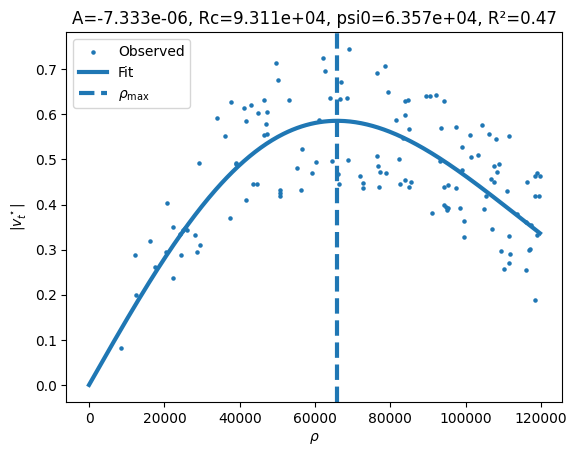

In [12]:
rho_outer = 120_000.0
dic_outer_mask_data = {}

Rc_opts, psi0_opts, A_opts = [], [], []

for k in range(len(df_multimodal_res)):
    data = df_multimodal_res.iloc[k]
    time = data.time  # or data.Time if that's your column

    ut = ds_sat.u.sel(time=time).values.ravel()
    vt = ds_sat.v.sel(time=time).values.ravel()

    m = (df_drifters["time"].to_numpy() >= (time - dt)) & (df_drifters["time"].to_numpy() <= (time + dt))
    dfm = df_drifters.iloc[np.flatnonzero(m)]
    xd, yd = dfm["x"].to_numpy(), dfm["y"].to_numpy()
    ud, vd = dfm["u"].to_numpy(), dfm["v"].to_numpy()

    xi = np.concatenate([xd, xg])
    yi = np.concatenate([yd, yg])
    ui = np.concatenate([ud, ut])
    vi = np.concatenate([vd, vt])

    xc, yc, Q, A = float(data.xc), float(data.yc), np.asarray(data.Q), float(data.A)
    q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]

    dx = xi - xc
    dy = yi - yc
    rho2 = q11*dx*dx + 2*q12*dx*dy + q22*dy*dy

    outer = rho2 <= rho_outer**2
    xi_o, yi_o, ui_o, vi_o = xi[outer], yi[outer], ui[outer], vi[outer]
    dx_o, dy_o, rho2_o = dx[outer], dy[outer], rho2[outer]

    dic_outer_mask_data[time] = pd.DataFrame({"xi": xi_o, "yi": yi_o, "ui": ui_o, "vi": vi_o})

    vt_o = tangential_velocity(xi_o, yi_o, ui_o, vi_o, xc, yc, Q)
    Qr_o = np.sqrt((Q[0,0]*dx_o + Q[1,0]*dy_o)**2 + (Q[1,0]*dx_o + Q[1,1]*dy_o)**2)

    sign_mask = (vt_o <= 0) if (A < 0) else (vt_o >= 0)
    rho2_f, Qr_f, vt_f = rho2_o[sign_mask], Qr_o[sign_mask], vt_o[sign_mask]

    Rc_opt, psi0_opt, A_opt = fit_psi_params(rho2_f, Qr_f, vt_f, A0=A, plot=True if k==10 else False)
    Rc_opts.append(Rc_opt); psi0_opts.append(psi0_opt); A_opts.append(A_opt)

df_multimodal_res["Rc"] = Rc_opts
df_multimodal_res["psi0"] = psi0_opts
df_multimodal_res["A_opt"] = A_opts
df_multimodal_res


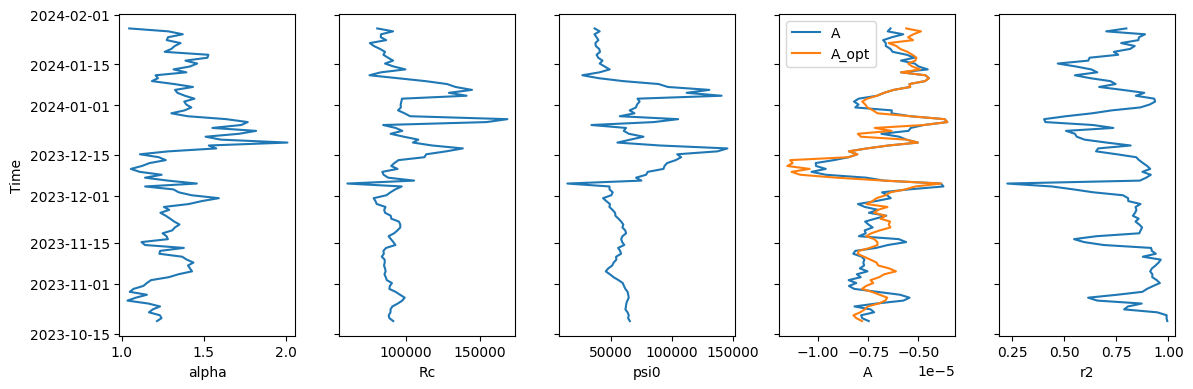

In [13]:
fig, axs = plt.subplots(1, 5, sharey=True, figsize=(12,4))

cols = ["alpha", "Rc", "psi0", "A", "r2"]

for ax, c in zip(axs, cols):
    ax.plot(df_multimodal_res[c], df_multimodal_res.time)
    ax.set_xlabel(c)

# overlay A_opt
axs[3].plot(df_multimodal_res.A_opt, df_multimodal_res.time)
axs[3].legend(["A", "A_opt"])

axs[0].set_ylabel("Time")

plt.tight_layout()


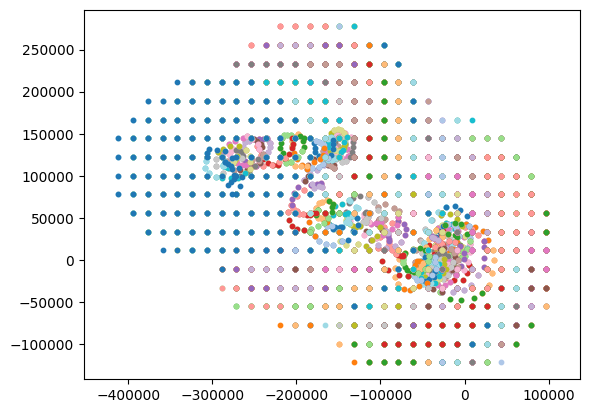

In [14]:
cmap = plt.colormaps['tab20']
for k, (key, df) in enumerate(dic_outer_mask_data.items()):
    plt.scatter(df.xi, df.yi, s=10, color=cmap(k % cmap.N))
plt.axis("equal")
plt.show()


In [15]:
X = ds_sat.x.values
Y = ds_sat.y.values
nt = len(df_multimodal_res)

U = np.empty((nt, X.shape[0], X.shape[1]))
V = np.empty((nt, X.shape[0], X.shape[1]))

for k in range(nt):
    data = df_multimodal_res.iloc[k]

    dx = X - data.xc
    dy = Y - data.yc

    q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]

    rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2
    fac = data.A_opt * np.exp(-rho2 / data.Rc**2)

    U[k] = -fac * (2*q12*dx + 2*q22*dy)
    V[k] =  fac * (2*q11*dx + 2*q12*dy)

mask = ds_sat.land_mask.values[None, :, :]   # (1, lat, lon)
U = np.where(mask, np.nan, U)
V = np.where(mask, np.nan, V)

ds_model = xr.Dataset(
    data_vars=dict(
        u=(("time","lat","lon"), U),
        v=(("time","lat","lon"), V),
    ),
    coords=dict(
        time=df_multimodal_res.time.values,
        lat=ds_sat.lat.values,
        lon=ds_sat.lon.values,
        x=(("lat","lon"), X),
        y=(("lat","lon"), Y),
    ),
)


In [28]:
def plot_sat_vs_model(df_res, ds_sat, ds_model, time=None, spac=1, scale=20,
                      xlim=(-410, 200), ylim=(-160, 260), out_thresh=False):

    if time is None:
        time = ds_model.time.values[0]

    sat = ds_sat.sel(time=time, method="nearest")
    mod = ds_model.sel(time=time, method="nearest")
    data = df_res[df_res.time == time].iloc[0]

    X = sat.x.values / 1e3
    Y = sat.y.values / 1e3

    us, vs = sat.u.values, sat.v.values
    um, vm = mod.u.values, mod.v.values

    sp_s = np.hypot(us, vs)
    sp_m = np.hypot(um, vm)

    # ROI mask in km-space
    roi = (X >= xlim[0]) & (X <= xlim[1]) & (Y >= ylim[0]) & (Y <= ylim[1])

    sp_s_roi = np.where(roi, sp_s, np.nan)
    sp_m_roi = np.where(roi, sp_m, np.nan)

    # combine the two fields to determine colour scale
    vals = np.concatenate([sp_s_roi[roi], sp_m_roi[roi]])
    vmin, vmax = np.nanmin(vals), np.nanmax(vals)

    levels = np.linspace(vmin, vmax, 30)   # shared contour levels

    # ellipse contour uses meters for rho2, but plotted on km grid
    dx = sat.x.values - data.xc
    dy = sat.y.values - data.yc
    rho2 = data.Q[0,0]*dx**2 + 2*data.Q[1,0]*dx*dy + data.Q[1,1]*dy**2

    fig, axs = plt.subplots(1, 2, figsize=(12,5), sharex=True, sharey=True, constrained_layout=True)

    # ---- Satellite ----
    h0 = axs[0].contourf(X, Y, sp_s_roi, levels=levels, cmap="Blues_r")

    axs[0].quiver(X[::spac,::spac], Y[::spac,::spac],
                  np.where(roi[::spac,::spac], us[::spac,::spac], np.nan),
                  np.where(roi[::spac,::spac], vs[::spac,::spac], np.nan),
                  scale=scale)

    axs[0].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50)
    axs[0].contour(X, Y, rho2, levels=[(data.Rc**2)/2], colors="r", linewidths=2) 
    if out_thresh:
        axs[0].contour(X, Y, rho2, levels=[120_000**2], colors="r", linewidths=2, linestyles='--')
    axs[0].plot(df_res.xc/1e3, df_res.yc/1e3, color="r", lw=.5)
    axs[0].set_title("Satellite")
    axs[0].set_aspect("equal")

    # ---- Model ----
    h1 = axs[1].contourf(X, Y, sp_m_roi, levels=levels, cmap="Blues_r")

    axs[1].quiver(X[::spac,::spac], Y[::spac,::spac],
                  np.where(roi[::spac,::spac], um[::spac,::spac], np.nan),
                  np.where(roi[::spac,::spac], vm[::spac,::spac], np.nan),
                  scale=scale)

    axs[1].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50)
    axs[1].contour(X, Y, rho2, levels=[(data.Rc**2)/2], colors="r", linewidths=2)
    if out_thresh:
        axs[1].contour(X, Y, rho2, levels=[120_000**2], colors="r", linewidths=2, linestyles='--')
    axs[1].set_title("Model")
    axs[1].set_aspect("equal")

    gap = 20
    for ax in axs:
        ax.set_xlim(xlim[0]+gap, xlim[1]-gap)
        ax.set_ylim(ylim[0]+gap, ylim[1]-gap)
        ax.set_xlabel("x (km)")
    axs[0].set_ylabel("y (km)")

    fig.colorbar(h1, ax=axs, label="Speed (m/s)", fraction=0.03, pad=0.02)
    fig.suptitle(f"time ≈ {np.datetime_as_string(time, unit='m')}")
    plt.show()


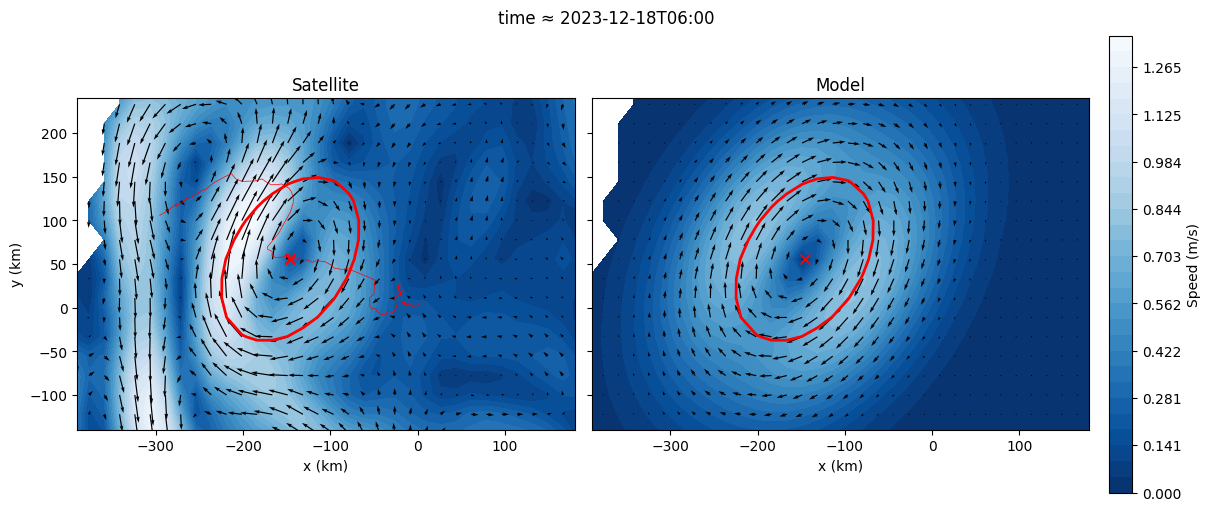

In [29]:
plot_sat_vs_model(df_multimodal_res, ds_sat, ds_model, time=df_multimodal_res.time.values[60])
